In [29]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder,FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.cluster import KMeans
from sklearn.pipeline import FeatureUnion
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from imblearn.pipeline import Pipeline 
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from xgboost import XGBClassifier


Vamos a relizar 5 modelos supervisados tenemos clasificación y usamos un modelo no supervisado 

Regresión Logística (Logistic Regression)

Bosques Aleatorios (Random Forest)

Máquina de Vectores de Soporte (SVC)

Gradient Boosting

K-Nearest Neighbors (KNN)

KMeans -> Descartado

PCA -> Aprobado



In [30]:
df = pd.read_csv('../data/processed/dataset_final.csv')

X = df.drop(['Churn','TotalCharges','gender','PhoneService','Dependents','MultipleLines',], axis=1)
y = df['Churn']



In [31]:
df

,gender,SeniorCitizen,Partner,Dependents,Antiguedad,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [32]:
#conversión de las columnas binarias . Por ejemplo las que son TRUE / False se conviertente a 1 / 0
le = LabelEncoder()
y = le.fit_transform(y)

In [33]:
# Seleccionamos las features de cada tipo, categoricas y númericas para luego poder preprocesarlas.
num_features = ['Antiguedad', 'MonthlyCharges']
cat_features = ['InternetService', 'PaymentMethod', 'Contract', 
    'PaperlessBilling', 'OnlineSecurity', 'TechSupport','SeniorCitizen']
#log_features = ['TotalCharges']



In [34]:
# Creamos 1 pipeline por cada 1 de las features
pre_num = Pipeline(steps=[
    ('scaler', StandardScaler())
])
pre_cat = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])
pre_log = Pipeline(steps=[
    ('logaritmico', FunctionTransformer(np.log1p, validate=True))
])

In [35]:
# Creamos el ColumnTransformer
ct = ColumnTransformer(transformers=[
    #('log', pre_log, log_features),
    ('num', pre_num, num_features),
    ('cat', pre_cat, cat_features)
])

In [36]:
# dividimos en train y test, recordamos siempre la regla del 80% / 20% para train y test y de paso guardamso la variable semilla a 42
semilla = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=semilla, stratify=y)

In [37]:
# diccionario con los modelos 
modelos = {
    'Regresion_Logistica': LogisticRegression(max_iter=1000, random_state=semilla,class_weight='balanced'),
    'Random_Forest': RandomForestClassifier(random_state=semilla,class_weight='balanced'),
    'SVM(SVC)': SVC(probability=True, random_state=semilla,class_weight='balanced'),
    'Gradient_Boosting': GradientBoostingClassifier(random_state=semilla),
    'K-NN': KNeighborsClassifier(),
    'XGBC': XGBClassifier()
}

In [ ]:
clusters=5 # numero de clusters, no pasarse
pipelines = {}
for name, model in modelos.items():

    pipelines[name] = Pipeline(steps=[
        ('preprocessor', ct),
        ('smote', SMOTE(k_neighbors=5,random_state=42)),
        ('PCA', PCA(n_components=0.95)), # AÑADIMOS PCA PARA VER SI ASI ELIMINAMOS LAS VARIABLES DUPLICADAS
        ('clasificador', model)
    ])

resultados = []
best_acc = 0
best_model_name = ""
best_cm = None 

for name, pipeline in pipelines.items():
    # 1. ENTRENAMIENTO
    pipeline.fit(X_train, y_train)

    # 2. PREDICCIONES
    y_pred_train = pipeline.predict(X_train)
    y_pred_test = pipeline.predict(X_test)
    
    y_pred_proba_test = pipeline.predict_proba(X_test)[:, 1]
    
    # 3. CÁLCULO DE MÉTRICAS
    # --- Métricas de TRAIN ---
    acc_train = accuracy_score(y_train, y_pred_train)
    rec_train = recall_score(y_train, y_pred_train)
    f1_train = f1_score(y_train, y_pred_train)
    
    # --- Métricas de TEST ---
    acc_test = accuracy_score(y_test, y_pred_test)
    rec_test = recall_score(y_test, y_pred_test)
    prec_test = precision_score(y_test, y_pred_test)
    f1_test = f1_score(y_test, y_pred_test)
    roc_auc_test = roc_auc_score(y_test, y_pred_proba_test)
    
    # 4. GUARDAR RESULTADOS
    resultados.append({
        'Modelo': name, 
        'Acc_Train': round(acc_train, 4),
        'Acc_Test': round(acc_test, 4),
        'Rec_Train': round(rec_train, 4),   # <--- Nueva columna
        'Rec_Test': round(rec_test, 4),
        'F1_Train': round(f1_train, 4),
        'F1_Test': round(f1_test, 4),
        'Prec_Test': round(prec_test, 4),
        'ROC-AUC_Test': round(roc_auc_test, 4)
    })  
    
    # 5. SELECCIÓN DEL MEJOR MODELO (Basado en Test)
    if acc_test > best_acc:
        best_acc = acc_test
        best_model_name = name
        best_cm = confusion_matrix(y_test, y_pred_test)

# Mostrar tabla comparativa
resultados = pd.DataFrame(resultados)
print(resultados)

                Modelo  Acc_Train  Acc_Test  Rec_Train  Rec_Test  F1_Train  \
0  Regresion_Logistica     0.7558    0.7367     0.7766    0.7781    0.6279   
1        Random_Forest     0.9959    0.7537     0.9940    0.6176    0.9923   
2             SVM(SVC)     0.7655    0.7445     0.7980    0.7594    0.6436   
3    Gradient_Boosting     0.7819    0.7495     0.8308    0.7594    0.6690   
4                 K-NN     0.8284    0.7140     0.8729    0.6818    0.7297   
5                 XGBC     0.9098    0.7516     0.9458    0.6765    0.8477   

   F1_Test  Prec_Test  ROC-AUC_Test  
0   0.6107     0.5026        0.8358  
1   0.5711     0.5310        0.8001  
2   0.6121     0.5126        0.8131  
3   0.6167     0.5192        0.8356  
4   0.5586     0.4731        0.7688  
5   0.5911     0.5249        0.8078  


In [39]:
results_df = pd.DataFrame(resultados).sort_values(by='Rec_Test', ascending=False)
print("Resumen Completo de Métricas:")
print(results_df.to_string(index=False))
print("Matriz de Confusión del mejor modelo:")
print(best_cm)
print (best_model_name)

Resumen Completo de Métricas:
             Modelo  Acc_Train  Acc_Test  Rec_Train  Rec_Test  F1_Train  F1_Test  Prec_Test  ROC-AUC_Test
Regresion_Logistica     0.7558    0.7367     0.7766    0.7781    0.6279   0.6107     0.5026        0.8358
           SVM(SVC)     0.7655    0.7445     0.7980    0.7594    0.6436   0.6121     0.5126        0.8131
  Gradient_Boosting     0.7819    0.7495     0.8308    0.7594    0.6690   0.6167     0.5192        0.8356
               K-NN     0.8284    0.7140     0.8729    0.6818    0.7297   0.5586     0.4731        0.7688
               XGBC     0.9098    0.7516     0.9458    0.6765    0.8477   0.5911     0.5249        0.8078
      Random_Forest     0.9959    0.7537     0.9940    0.6176    0.9923   0.5711     0.5310        0.8001
Matriz de Confusión del mejor modelo:
[[831 204]
 [143 231]]
Random_Forest


In [40]:
results_df.to_csv('../data/processed/resultados_modelos.csv', index=False)

In [41]:
mejor_pipeline = pipelines[best_model_name]
preprocesado = mejor_pipeline.named_steps['preprocessor'].transform(X_test)
X_pca = mejor_pipeline.named_steps['PCA'].transform(preprocesado)

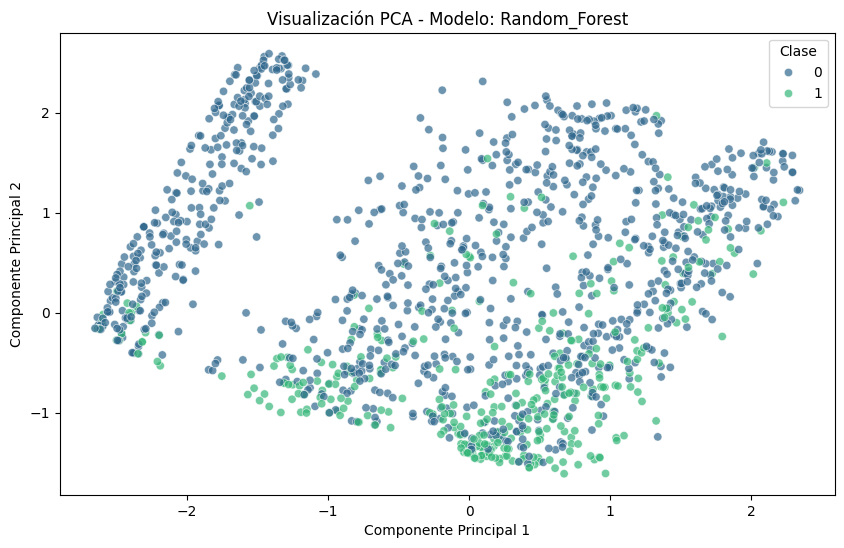

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_pca[:, 0], 
    y=X_pca[:, 1], 
    hue=y_test, # Coloreamos por la clase real
    palette='viridis',
    alpha=0.7
)

plt.title(f'Visualización PCA - Modelo: {best_model_name}')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Clase')
plt.show()

In [43]:
results_df

,Modelo,Acc_Train,Acc_Test,Rec_Train,Rec_Test,F1_Train,F1_Test,Prec_Test,ROC-AUC_Test
0,Regresion_Logistica,0.7558,0.7367,0.7766,0.7781,0.6279,0.6107,0.5026,0.8358
2,SVM(SVC),0.7655,0.7445,0.7980,0.7594,0.6436,0.6121,0.5126,0.8131
3,Gradient_Boosting,0.7819,0.7495,0.8308,0.7594,0.6690,0.6167,0.5192,0.8356
4,K-NN,0.8284,0.7140,0.8729,0.6818,0.7297,0.5586,0.4731,0.7688
5,XGBC,0.9098,0.7516,0.9458,0.6765,0.8477,0.5911,0.5249,0.8078
1,Random_Forest,0.9959,0.7537,0.9940,0.6176,0.9923,0.5711,0.5310,0.8001


In [44]:
# Guardar modelos por separado

for nombre, pipeline in pipelines.items():
    # Limpiamos el nombre para que no tenga espacios ni paréntesis en el archivo
    nombre_limpio = nombre.replace(" ", "_").replace("(", "").replace(")", "")
    nombre_archivo = f"../models/trained_model_{nombre_limpio}.pkl"
    
    # Guardamos el pipeline individual directamente en la ruta actual
    joblib.dump(pipeline, nombre_archivo)
    print(f" -> Guardado: {nombre_archivo}")

print("\n¡Todos los modelos han sido guardados individualmente!")

 -> Guardado: ../models/trained_model_Regresion_Logistica.pkl
 -> Guardado: ../models/trained_model_Random_Forest.pkl
 -> Guardado: ../models/trained_model_SVMSVC.pkl
 -> Guardado: ../models/trained_model_Gradient_Boosting.pkl
 -> Guardado: ../models/trained_model_K-NN.pkl
 -> Guardado: ../models/trained_model_XGBC.pkl

¡Todos los modelos han sido guardados individualmente!


In [ ]:
modelo_seleccionado = modelos['Regresion_Logistica']

modelo_final = Pipeline([
    ('preprocessor', ct),
    ('PCA', PCA(n_components=0.95)), # AÑADIMOS PCA PARA VER SI ASI ELIMINAMOS LAS VARIABLES DUPLICADAS # pasamos los mismos trasnfromadores que en el for de todos los modelos.
    ('smote', SMOTE(random_state=42)),
    ('clasificador', modelo_seleccionado) # modelo seleccionado con mejor metrica / velocidad
])

# definimos los parametros del gridsearch
param_grid = [
    {
        'clasificador__solver': ['liblinear'], 
        'clasificador__penalty': ['l1', 'l2'], 
        'clasificador__C': [0.001, 0.01, 0.1, 1, 10],
    },
    {
        'clasificador__solver': ['lbfgs'], 
        'clasificador__penalty': ['l2'], 
        'clasificador__C': [0.001, 0.01, 0.1, 1, 10],
        'clasificador__max_iter': [1000],
    }
]

grid_search = GridSearchCV(
    estimator=modelo_final, # pipeline solo del modelo ganador
    param_grid=param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1
)

In [56]:
grid_search.fit(X_train, y_train)

InvalidParameterError: The 'scoring' parameter of GridSearchCV must be a str among {'d2_brier_score', 'matthews_corrcoef', 'jaccard', 'neg_root_mean_squared_error', 'f1_micro', 'neg_mean_squared_error', 'recall_weighted', 'explained_variance', 'mutual_info_score', 'neg_brier_score', 'positive_likelihood_ratio', 'adjusted_rand_score', 'jaccard_macro', 'jaccard_samples', 'recall', 'f1', 'roc_auc_ovo', 'precision_weighted', 'adjusted_mutual_info_score', 'precision_micro', 'normalized_mutual_info_score', 'balanced_accuracy', 'd2_log_loss_score', 'neg_mean_absolute_percentage_error', 'neg_root_mean_squared_log_error', 'top_k_accuracy', 'neg_mean_absolute_error', 'f1_samples', 'roc_auc_ovo_weighted', 'f1_weighted', 'neg_mean_squared_log_error', 'fowlkes_mallows_score', 'neg_log_loss', 'rand_score', 'neg_mean_poisson_deviance', 'd2_absolute_error_score', 'neg_negative_likelihood_ratio', 'homogeneity_score', 'roc_auc_ovr', 'v_measure_score', 'average_precision', 'precision_macro', 'neg_median_

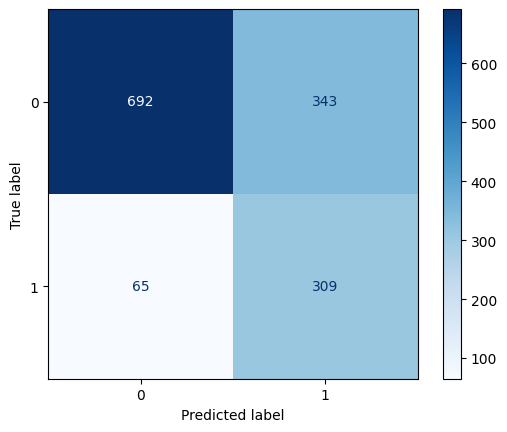

In [47]:
y_pred = grid_search.predict(X_test)

# 4. Generar la matriz
cm = confusion_matrix(y_test, y_pred)

# 5. Visualizar
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=grid_search.classes_)
disp.plot(cmap='Blues')

In [48]:
print("Mejores hiperparámetros:")
print(grid_search.best_params_)

# Mostrar el mejor "score" (exactitud media en validación cruzada)
print(f"\nMejor exactitud (CV Score): {grid_search.best_score_:.4f}")

Mejores hiperparámetros:
{'clasificador__C': 0.001, 'clasificador__penalty': 'l1', 'clasificador__solver': 'liblinear'}

Mejor exactitud (CV Score): 0.7900


In [49]:
resultados_df = pd.DataFrame(grid_search.cv_results_)

# Seleccionar solo las columnas que más importan y ordenarlas por el mejor resultado
resumen = resultados_df[['rank_test_score', 'mean_test_score', 'params']]
resumen_ordenado = resumen.sort_values(by='rank_test_score')

In [50]:
resumen_ordenado

,rank_test_score,mean_test_score,params
0,1,0.789967,"{'clasificador__C': 0.001, 'clasificador__pena..."
1,2,0.781940,"{'clasificador__C': 0.001, 'clasificador__pena..."
10,3,0.779933,"{'clasificador__C': 0.001, 'clasificador__max_..."
2,4,0.777926,"{'clasificador__C': 0.01, 'clasificador__penal..."
6,5,0.775251,"{'clasificador__C': 1, 'clasificador__penalty'..."
5,6,0.774582,"{'clasificador__C': 0.1, 'clasificador__penalt..."
8,6,0.774582,"{'clasificador__C': 10, 'clasificador__penalty..."
9,6,0.774582,"{'clasificador__C': 10, 'clasificador__penalty..."
14,6,0.774582,"{'clasificador__C': 10, 'clasificador__max_ite..."
13,6,0.774582,"{'clasificador__C': 1, 'clasificador__max_iter..."


In [51]:
#seleccionamso el mejor estimador
mejor_pipeline_final = grid_search.best_estimator_

#guardamos el modelo que será el que usemos para predecir.
nombre_archivo = '../models/final_model.pkl'
joblib.dump(mejor_pipeline_final, nombre_archivo)

['../models/final_model.pkl']

In [52]:
modelo_produccion = joblib.load('../models/final_model.pkl')

nuevos_datos = pd.DataFrame({
    # Numéricas
    'Antiguedad':[12,34],
    'SeniorCitizen':[0,1],
    'MonthlyCharges': [23,65],
    'TotalCharges': [3500,2300],
    # Categóricas
    'gender':['Male','Female'],
    'Partner':['No','Yes'] ,
    'Dependents':['No','Yes'] ,
    'PhoneService':['No','Yes']  ,
    'MultipleLines':['No','Yes']  , 
    'InternetService':['No','Yes']  ,
    'OnlineSecurity':['No','Yes']  ,
    'OnlineBackup':['No','Yes']  ,
    'DeviceProtection':['No','Yes']  , 
    'TechSupport': ['No','Yes'] ,
    'StreamingTV': ['No','Yes']  ,
    'StreamingMovies': ['No','Yes']  ,
    'Contract': ['Month-to-month','One Year'],
    'PaperlessBilling':['No','Yes'] ,
    'PaymentMethod':['Mailed check', 'Electronic check'] 
})

predicciones = modelo_produccion.predict(nuevos_datos)
probabilidades = modelo_produccion.predict_proba(nuevos_datos)

# 5. Visualizar el resultado final
nuevos_datos['Prediccion_Modelo'] = predicciones
nuevos_datos['Crush Rate'] = probabilidades[:, 1] # Probabilidad de ser la clase positiva

print("--- RESULTADOS DE LAS PREDICCIONES ---")
print(nuevos_datos[['Antiguedad', 'PaymentMethod', 'Prediccion_Modelo', 'Crush Rate']])

--- RESULTADOS DE LAS PREDICCIONES ---
   Antiguedad     PaymentMethod  Prediccion_Modelo  Crush Rate
0          12      Mailed check                  1    0.510678
1          34  Electronic check                  0    0.477790


/home/danilavia/.local/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/danilavia/.local/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [53]:
# Ponemos a prueba el modelo con un csv generado sinteticamente.

modelo_produccion = joblib.load('../models/final_model.pkl')
# 2. Recibir o crear los DATOS NUEVOS
# IMPORTANTE: Deben ser las mismas columnas con las que entrenaste (X_train)
csv = pd.read_csv('../data/processed/datos_prueba_ml2.csv')

predicciones = modelo_produccion.predict(csv)
probabilidades = modelo_produccion.predict_proba(csv)

# 5. Visualizar el resultado final
csv['Prediccion_Modelo'] = predicciones
csv['Crush Rate'] = probabilidades[:, 1] # Probabilidad de ser la clase positiva

print("--- RESULTADOS DE LAS PREDICCIONES ---")
print(csv[['customerID','Antiguedad', 'PaymentMethod', 'Prediccion_Modelo', 'Crush Rate']])



--- RESULTADOS DE LAS PREDICCIONES ---
         customerID  Antiguedad              PaymentMethod  Prediccion_Modelo  \
0     sdv-id-pJvgxt          43           Electronic check                  0   
1     sdv-id-QZoJix          29               Mailed check                  0   
2     sdv-id-sUpodm          71    Credit card (automatic)                  0   
3     sdv-id-VQZvMN           3               Mailed check                  1   
4     sdv-id-fHaBym          19    Credit card (automatic)                  0   
...             ...         ...                        ...                ...   
2995  sdv-id-Fmtawh          70           Electronic check                  0   
2996  sdv-id-rxOgFc          13           Electronic check                  1   
2997  sdv-id-jBlECX          32  Bank transfer (automatic)                  0   
2998  sdv-id-qROYcp          35    Credit card (automatic)                  0   
2999  sdv-id-TcDbKz           4           Electronic check            

In [54]:
csv.to_csv('../data/processed/datos_procesados.csv', index=False)